In [33]:
import os
import glob
import time
import math

import io
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter1d

from app.routers.soyanalysis import *

In [27]:
image_path_list = glob.glob(os.path.join("images", "mk2", "image", "*", "*", "*.jpg"))
print(len(image_path_list))

150


In [ ]:
# os.rmdir("./results/images") if os.path.exists("./results/images") else None
os.makedirs("./results/images")

multi_result_dict = {}
for idx, image_path in enumerate(image_path_list):
    try:
        print(f"[{idx+1}/{len(image_path_list)}] Processing:", image_path)
              
        pil_image = Image.open(image_path).convert("RGB")
        input_w, input_h = pil_image.size
        # if input_w < input_h:
        #     pil_image = pil_image.transpose(Image.ROTATE_270)
        #     input_w, input_h = pil_image.size
        # print("image size: ", pil_image.size)

        # rotated_input_pil = image.rotate(90, expand=True)
        # rotated_input_filename = get_save_path("uploads", "jpg")
        # rotated_input_pil.save(rotated_input_filename)

        img = np.array(pil_image)
        img = cv2.resize(img, (1920, 1080))
        gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        line_results, line_cropped_image = find_edges_line(gray_image, 24000, 16000)
        # line_results, line_cropped_image = find_edges_max(gray_image, 80, 24000, 8000)
        print("line cropped image shape:", line_cropped_image.shape)
        
        cropped_image = img[line_results['top']-20:line_results['bottom']+20, line_results['left']:line_results['right']]
        cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
        
        left_crop_ratio = 0.24
        right_crop_ratio = 0.72
        analysis_image = line_cropped_image[:, int(line_cropped_image.shape[1]*left_crop_ratio):int(line_cropped_image.shape[1]*right_crop_ratio)]
        print("mark cropped image shape:", analysis_image.shape)

        analysis_graph, width, min_index = analyze_analyze(analysis_image, sigma=24)
        marks, pixel_values = crop_zero2fifth(analysis_image)
        # predict_value, sorted_marks = get_prediction(marks, min_index)
        predict_value, sorted_marks = get_fixed_prediction(marks, min_index, analysis_image.shape[1])

        analysis_image_color = cv2.cvtColor(analysis_image, cv2.COLOR_GRAY2BGR)
        cv2.line(analysis_image_color, (min_index, 0), (min_index, analysis_image_color.shape[0]), (0, 0, 255), 2)
        for m in sorted_marks:
            cv2.line(analysis_image_color, (m[1], 0), (m[1], analysis_image_color.shape[0]), (0, 0, 0), 2)
        # cv2.rectangle(
        #     analysis_image_color,
        #     (min_index-30, 2),
        #     (min_index+30, analysis_image_color.shape[0]-2),
        #     (255, 0, 0),
        #     3
        # )
        
        image_dirname = os.path.dirname(image_path)
        image_bn = os.path.basename(image_path)
        os.makedirs(os.path.join("./results", image_dirname), exist_ok=True)
        result_image_path = os.path.join("./results", image_dirname, f"image_{image_bn}")
        graph_image_path = os.path.join("./results", image_dirname, f"graph_{image_bn}")
        # Image.fromarray(cv2.rotate(analysis_image_color, cv2.ROTATE_90_COUNTERCLOCKWISE)).save(result_image_path)
        Image.fromarray(analysis_image_color).save(result_image_path)
        Image.fromarray(analysis_graph).save(graph_image_path)

        multi_result_dict[idx] = {
            "image_path": image_path,
            "predict_value": predict_value,
            "width": width,
            "min_index": min_index,
            "gt": os.path.split(os.path.split(image_dirname)[0])[1],
            "light": os.path.split(image_dirname)[1]
        }
        print(f"Saved result image to: {result_image_path}")
        print(f"  → predict_value={predict_value}, width={width}, min_index={min_index}")

    except Exception as e:
        print("Error:", image_path, str(e))

[1/150] Processing: images\mk2\image\6\1\WIN_20251002_17_52_57_Pro.jpg
{'top': 435, 'bottom': 916, 'left': 420, 'right': 956}
line cropped image shape: (481, 536)
mark cropped image shape: (481, 257)
min_index: 220 / min_value: -0.47891139435078856
min_value2_index: 149 / min_value2: -0.23945569717539428
width: 71
peaks: [71]
left_crop_image shape: (481, 257)
marks: [np.int64(36), np.int64(159)]
Saved result image to: ./results\images\mk2\image\6\1\image_WIN_20251002_17_52_57_Pro.jpg
  → predict_value=15.6, width=71, min_index=220
[2/150] Processing: images\mk2\image\6\1\WIN_20251002_17_53_44_Pro.jpg
{'top': 438, 'bottom': 917, 'left': 421, 'right': 952}
line cropped image shape: (479, 531)
mark cropped image shape: (479, 255)
min_index: 213 / min_value: -0.47125797221353594
min_value2_index: 150 / min_value2: -0.23562898610676797
width: 63
peaks: [63]
left_crop_image shape: (479, 255)
marks: [np.int64(35), np.int64(158)]
Saved result image to: ./results\images\mk2\image\6\1\image_WIN_

In [ ]:
df = pd.DataFrame.from_dict(multi_result_dict, orient="index")
print(df.head())
print(df.shape)

                                          image_path  predict_value  width  \
0  images\mk2\image\6\1\WIN_20251002_17_52_57_Pro...           15.6     71   
1  images\mk2\image\6\1\WIN_20251002_17_53_44_Pro...           15.2     63   
2  images\mk2\image\6\1\WIN_20251002_17_53_45_Pro...           15.2     77   
3  images\mk2\image\6\1\WIN_20251002_17_53_46_Pro...           15.5     74   
4  images\mk2\image\6\1\WIN_20251002_17_53_48_Pro...           15.2     59   

   min_index gt light  
0        220  6     1  
1        213  6     1  
2        213  6     1  
3        215  6     1  
4        212  6     1  
(150, 6)


In [43]:
print("GT levels:", sorted(df["gt"].unique()))
print("Light levels:", sorted(df["light"].unique()))

print(df.groupby(["gt", "light"]).size())

GT levels: ['6', '7', '8']
Light levels: ['1', '2', '3', '4', '5']
gt  light
6   1        10
    2        10
    3        10
    4        10
    5        10
7   1        10
    2        10
    3        10
    4        10
    5        10
8   1        10
    2        10
    3        10
    4        10
    5        10
dtype: int64


In [46]:
gt_stats = (
    df.groupby("gt")["predict_value"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)
light_stats = (
    df.groupby("light")["predict_value"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)
gt_light_stats = (
    df.groupby(["gt", "light"])["predict_value"]
    .agg(["count", "mean", "std"])
    .reset_index()
)

In [47]:
print("=== GT Stats ===")
print(gt_stats)
print("=== Light Stats ===")
print(light_stats)
print("=== GT and Light Stats ===")
print(gt_light_stats)

=== GT Stats ===
  gt  count   mean       std  min   max
0  6     50  7.476  3.993799  5.3  15.6
1  7     50  8.806  3.458406  6.9  15.9
2  8     50  9.478  3.129797  7.8  16.0
=== Light Stats ===
  light  count       mean       std   min   max
0     1     30  15.566667  0.249597  15.0  16.0
1     2     30   6.926667  1.032217   5.5   8.1
2     3     30   6.786667  1.060492   5.3   8.0
3     4     30   6.833333  1.014833   5.5   7.9
4     5     30   6.820000  0.998413   5.5   7.9
=== GT and Light Stats ===
   gt light  count   mean       std
0   6     1     10  15.38  0.214994
1   6     2     10   5.60  0.047140
2   6     3     10   5.40  0.047140
3   6     4     10   5.50  0.000000
4   6     5     10   5.50  0.000000
5   7     1     10  15.65  0.222361
6   7     2     10   7.12  0.063246
7   7     3     10   7.05  0.070711
8   7     4     10   7.10  0.000000
9   7     5     10   7.11  0.031623
10  8     1     10  15.67  0.216282
11  8     2     10   8.06  0.051640
12  8     3     10  

In [51]:
df2 = df.copy()
df2["gt"] = df2["gt"].astype(float)
df2["error"] = df2["predict_value"] - df2["gt"]

mae = df2["error"].abs().mean()
rmse = np.sqrt((df2["error"] ** 2).mean())

print(f"MAE  (overall): {mae:.4f}")
print(f"RMSE (overall): {rmse:.4f}")

MAE  (overall): 1.9000
RMSE (overall): 3.8547


In [58]:
light_stats = (
    df2
    .groupby("light")
    .apply(lambda g: pd.Series({
        "count": len(g),
        "MAE": g["error"].abs().mean(),
        "RMSE": np.sqrt((g["error"] ** 2).mean())
    }))
    .reset_index()
)
gt_stats = (
    df2
    .groupby("gt")
    .apply(lambda g: pd.Series({
        "count": len(g),
        "MAE": g["error"].abs().mean(),
        "RMSE": np.sqrt((g["error"] ** 2).mean())
    }))
    .reset_index()
)
gt_light_stats = (
    df2
    .groupby(["gt", "light"])
    .apply(lambda g: pd.Series({
        "count": len(g),
        "MAE": g["error"].abs().mean(),
        "RMSE": np.sqrt((g["error"] ** 2).mean())
    }))
    .reset_index()
)
print(light_stats)
print(gt_stats)
print(gt_light_stats)

  light  count       MAE      RMSE
0     1   30.0  8.566667  8.597752
1     2   30.0  0.193333  0.248998
2     3   30.0  0.253333  0.354965
3     4   30.0  0.233333  0.300000
4     5   30.0  0.253333  0.309839
    gt  count    MAE      RMSE
0  6.0   50.0  2.276  4.220190
1  7.0   50.0  1.810  3.870788
2  8.0   50.0  1.614  3.432812
     gt light  count   MAE      RMSE
0   6.0     1   10.0  9.38  9.382217
1   6.0     2   10.0  0.40  0.402492
2   6.0     3   10.0  0.60  0.601664
3   6.0     4   10.0  0.50  0.500000
4   6.0     5   10.0  0.50  0.500000
5   7.0     1   10.0  8.65  8.652572
6   7.0     2   10.0  0.12  0.134164
7   7.0     3   10.0  0.07  0.083666
8   7.0     4   10.0  0.10  0.100000
9   7.0     5   10.0  0.11  0.114018
10  8.0     1   10.0  7.67  7.672744
11  8.0     2   10.0  0.06  0.077460
12  8.0     3   10.0  0.09  0.094868
13  8.0     4   10.0  0.10  0.100000
14  8.0     5   10.0  0.15  0.158114


C:\Users\ty\AppData\Local\Temp\ipykernel_55144\3490229899.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\ty\AppData\Local\Temp\ipykernel_55144\3490229899.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\ty\AppData\Local\Temp\ipykernel_55144\3490229899.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the groupin

Example image path: images\mk2\image\6\4\WIN_20251002_17_57_11_Pro.jpg
{'top': 435, 'bottom': 920, 'left': 414, 'right': 1400}


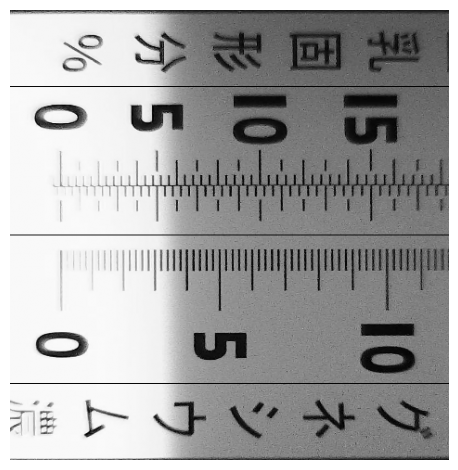

In [103]:
example_img = image_path_list[30]
print("Example image path:", example_img)

img_array = np.fromfile(example_img, np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
img = cv2.resize(img.copy(), (1920, 1080))
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
line_results, line_cropped_image = find_edges_line(gray_image, 24000, 16000)
left_crop_ratio = 0.24
right_crop_ratio = 0.72
analysis_image = line_cropped_image[:, int(line_cropped_image.shape[1]*left_crop_ratio):int(line_cropped_image.shape[1]*right_crop_ratio)]
w, h = analysis_image.shape[1], analysis_image.shape[0]
cv2.line(analysis_image, (0, h//2), (w, h//2), (0, 0, 0), 1)
cv2.line(analysis_image, (0, h//2+160), (w, h//2+160), (0, 0, 0), 1)
cv2.line(analysis_image, (0, h//2-160), (w, h//2-160), (0, 0, 0), 1)
# cv2.line(analysis_image, (0, h//2+5), (w, h//2+5), (0, 0, 0), 1)
# cv2.line(analysis_image, (0, h//2-5), (w, h//2-5), (0, 0, 0), 1)

plt.imshow(analysis_image, cmap='gray')
plt.axis('off')
plt.tight_layout()

In [ ]:
def analyze_multiline(analysis_image, sigma=24, line_offsets=(0, 160, -160)):
    h, w = analysis_image.shape
    center_y = h // 2

    line_results = []
    graph_canvas = np.zeros((h, w, 3), dtype=np.uint8)
    
    for dy in line_offsets:
        y = center_y + dy
        if y < 0 or y >= h:
            continue

        # 1D signal
        y_raw = analysis_image[y, :].reshape(-1).astype(float)
        y_smooth = gaussian_filter1d(y_raw, sigma=sigma)
        y_deriv = np.gradient(y_smooth)
        
        # derivative minimum
        min_index = int(np.argmin(y_deriv))
        min_value = y_deriv[min_index]

        # half-depth width
        half_value = min_value / 2
        left = min_index
        while left > 0 and y_deriv[left] < half_value:
            left -= 1
        width = min_index - left
        
        # single-peak check
        region = y_deriv[left:min_index + width]
        peaks, _ = find_peaks(-region, prominence=abs(min_value) * 0.2)
        valid = len(peaks) == 1

        line_results.append({
            "y": y,
            "min_index": min_index,
            "width": width,
            "valid": valid
        })
        
        # graph visualization
        deriv_norm = cv2.normalize(
            y_deriv, None, 0, 255, cv2.NORM_MINMAX
        ).astype(np.uint8)
        deriv_norm = deriv_norm.squeeze()

        graph_canvas[y, :, 0] = deriv_norm
        graph_canvas[y, :, 1] = deriv_norm
        graph_canvas[y, :, 2] = deriv_norm

        color = (0, 255, 0) if valid else (0, 0, 255)
        cv2.line(graph_canvas, (0, y), (w, y), color, 1)
        cv2.circle(graph_canvas, (min_index, y), 3, (255, 0, 0), -1)

    # ---------------------------
    # aggregation (중요)
    # ---------------------------
    valid_lines = [r for r in line_results if r["valid"]]

    if len(valid_lines) == 0:
        raise Exception("All multiline samples are unstable")

    min_index = int(np.median([r["min_index"] for r in valid_lines]))
    width = int(np.median([r["width"] for r in valid_lines]))

    return graph_canvas, width, min_index

In [102]:
if os.path.exists("./results/images_multi"):
    raise Exception("Directory already exists")
os.makedirs("./results/images_multi")

multi_result_dict = {}
line_offset = [0, 160, -160]
for idx, image_path in enumerate(image_path_list):
    try:
        print(f"[{idx+1}/{len(image_path_list)}] Processing:", image_path)
              
        pil_image = Image.open(image_path).convert("RGB")
        input_w, input_h = pil_image.size

        img = np.array(pil_image)
        img = cv2.resize(img, (1920, 1080))
        gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        line_results, line_cropped_image = find_edges_line(gray_image, 24000, 16000)
        # line_results, line_cropped_image = find_edges_max(gray_image, 80, 24000, 8000)
        print("line cropped image shape:", line_cropped_image.shape)
        
        cropped_image = img[line_results['top']-20:line_results['bottom']+20, line_results['left']:line_results['right']]
        cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
        
        left_crop_ratio = 0.24
        right_crop_ratio = 0.72
        analysis_image = line_cropped_image[:, int(line_cropped_image.shape[1]*left_crop_ratio):int(line_cropped_image.shape[1]*right_crop_ratio)]
        print("mark cropped image shape:", analysis_image.shape)

        analysis_graph, width, min_index = analyze_multiline(analysis_image, sigma=24)
        marks, pixel_values = crop_zero2fifth(analysis_image)
        # predict_value, sorted_marks = get_prediction(marks, min_index)
        predict_value, sorted_marks = get_fixed_prediction(marks, min_index, analysis_image.shape[1])

        analysis_image_color = cv2.cvtColor(analysis_image, cv2.COLOR_GRAY2BGR)
        cv2.line(analysis_image_color, (min_index, 0), (min_index, analysis_image_color.shape[0]), (0, 0, 255), 2)
        for m in sorted_marks:
            cv2.line(analysis_image_color, (m[1], 0), (m[1], analysis_image_color.shape[0]), (0, 0, 0), 2)

        image_dirname = os.path.dirname(image_path)
        image_bn = os.path.basename(image_path)
        os.makedirs(os.path.join("./results", image_dirname), exist_ok=True)
        result_image_path = os.path.join("./results", image_dirname, f"image_{image_bn}")
        graph_image_path = os.path.join("./results", image_dirname, f"graph_{image_bn}")
        Image.fromarray(analysis_image_color).save(result_image_path)
        Image.fromarray(analysis_graph).save(graph_image_path)

        multi_result_dict[idx] = {
            "image_path": image_path,
            "predict_value": predict_value,
            "width": width,
            "min_index": min_index,
            "gt": os.path.split(os.path.split(image_dirname)[0])[1],
            "light": os.path.split(image_dirname)[1]
        }
        print(f"Saved result image to: {result_image_path}")
        print(f"  → predict_value={predict_value}, width={width}, min_index={min_index}")

    except Exception as e:
        print("Error:", image_path, str(e))

[1/150] Processing: images\mk2\image\6\1\WIN_20251002_17_52_57_Pro.jpg
{'top': 435, 'bottom': 916, 'left': 420, 'right': 956}
line cropped image shape: (481, 536)
mark cropped image shape: (481, 257)
1
2
3
4
2
3
4
2
3
4
left_crop_image shape: (481, 257)
marks: [np.int64(36), np.int64(159)]
Saved result image to: ./results\images\mk2\image\6\1\image_WIN_20251002_17_52_57_Pro.jpg
  → predict_value=15.4, width=68, min_index=217
[2/150] Processing: images\mk2\image\6\1\WIN_20251002_17_53_44_Pro.jpg
{'top': 438, 'bottom': 917, 'left': 421, 'right': 952}
line cropped image shape: (479, 531)
mark cropped image shape: (479, 255)
1
2
3
4
2
3
4
2
3
4
left_crop_image shape: (479, 255)
marks: [np.int64(35), np.int64(158)]
Saved result image to: ./results\images\mk2\image\6\1\image_WIN_20251002_17_53_44_Pro.jpg
  → predict_value=15.4, width=63, min_index=215
[3/150] Processing: images\mk2\image\6\1\WIN_20251002_17_53_45_Pro.jpg
{'top': 438, 'bottom': 917, 'left': 421, 'right': 952}
line cropped ima

In [104]:
df_multi = pd.DataFrame.from_dict(multi_result_dict, orient="index")

# 타입 정리
df_multi["gt"] = df_multi["gt"].astype(float)
df_multi["predict_value"] = df_multi["predict_value"].astype(float)

# error 계산
df_multi["error"] = df_multi["predict_value"] - df_multi["gt"]

In [105]:
overall_mae = df_multi["error"].abs().mean()
overall_rmse = np.sqrt((df_multi["error"] ** 2).mean())

print("Overall MAE:", overall_mae)
print("Overall RMSE:", overall_rmse)

Overall MAE: 1.9086666666666663
Overall RMSE: 3.8686000913336422


In [106]:
light_stats = (
    df_multi
    .groupby("light")
    .apply(lambda g: pd.Series({
        "count": len(g),
        "MAE": g["error"].abs().mean(),
        "RMSE": np.sqrt((g["error"] ** 2).mean())
    }))
    .reset_index()
)
gt_stats = (
    df_multi
    .groupby("gt")
    .apply(lambda g: pd.Series({
        "count": len(g),
        "MAE": g["error"].abs().mean(),
        "RMSE": np.sqrt((g["error"] ** 2).mean())
    }))
    .reset_index()
)
gt_light_stats = (
    df_multi
    .groupby(["gt", "light"])
    .apply(lambda g: pd.Series({
        "count": len(g),
        "MAE": g["error"].abs().mean(),
        "RMSE": np.sqrt((g["error"] ** 2).mean())
    }))
    .reset_index()
)

print("=== Light-wise stats (multiline) ===")
print(light_stats)
print("=== GT-wise stats (multiline) ===")
print(gt_stats)
print("=== GT & Light stats (multiline) ===")
print(gt_light_stats)

=== Light-wise stats (multiline) ===
  light  count       MAE      RMSE
0     1   30.0  8.603333  8.628770
1     2   30.0  0.200000  0.250333
2     3   30.0  0.253333  0.354965
3     4   30.0  0.233333  0.300000
4     5   30.0  0.253333  0.309839
=== GT-wise stats (multiline) ===
    gt  count    MAE      RMSE
0  6.0   50.0  2.272  4.210843
1  7.0   50.0  1.816  3.883298
2  8.0   50.0  1.638  3.476636
=== GT & Light stats (multiline) ===
     gt light  count   MAE      RMSE
0   6.0     1   10.0  9.36  9.361197
1   6.0     2   10.0  0.40  0.402492
2   6.0     3   10.0  0.60  0.601664
3   6.0     4   10.0  0.50  0.500000
4   6.0     5   10.0  0.50  0.500000
5   7.0     1   10.0  8.68  8.680553
6   7.0     2   10.0  0.12  0.134164
7   7.0     3   10.0  0.07  0.083666
8   7.0     4   10.0  0.10  0.100000
9   7.0     5   10.0  0.11  0.114018
10  8.0     1   10.0  7.77  7.770650
11  8.0     2   10.0  0.08  0.089443
12  8.0     3   10.0  0.09  0.094868
13  8.0     4   10.0  0.10  0.100000
14 

C:\Users\ty\AppData\Local\Temp\ipykernel_55144\1838678736.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\ty\AppData\Local\Temp\ipykernel_55144\1838678736.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\ty\AppData\Local\Temp\ipykernel_55144\1838678736.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the groupin